<a href="https://colab.research.google.com/github/Geethikadedipya/ganproject5/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
batch_size = 128
learning_rate = 0.0002
epochs = 50
latent_dim = 100   # noise vector size


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(mnist, batch_size=batch_size, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 59.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.06MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=learning_rate)
optimizer_D = optim.Adam(D.parameters(), lr=learning_rate)


In [ ]:
for epoch in range(epochs):
    for real_images, _ in dataloader:
        real_images = real_images.view(-1, 28*28).to(device)
        batch_size = real_images.size(0)

        # Real and Fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---- Train Discriminator ----
        noise = torch.randn(batch_size, latent_dim).to(device)
        fake_images = G(noise)

        D_real = D(real_images)
        D_fake = D(fake_images.detach())

        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        output = D(fake_images)
        loss_G = criterion(output, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {loss_D.item():.4f}  Loss G: {loss_G.item():.4f}")


Epoch [1/50]  Loss D: 0.1647  Loss G: 5.3315
Epoch [2/50]  Loss D: 0.0493  Loss G: 6.6228
Epoch [3/50]  Loss D: 0.5493  Loss G: 5.1737
Epoch [4/50]  Loss D: 1.2993  Loss G: 2.1651
Epoch [5/50]  Loss D: 0.6325  Loss G: 2.4611
Epoch [6/50]  Loss D: 0.9504  Loss G: 2.2349
Epoch [7/50]  Loss D: 0.3788  Loss G: 2.6033
Epoch [8/50]  Loss D: 2.1336  Loss G: 1.2379
Epoch [9/50]  Loss D: 0.7223  Loss G: 2.1031
Epoch [10/50]  Loss D: 1.1645  Loss G: 3.2337
Epoch [11/50]  Loss D: 0.7373  Loss G: 3.9856
Epoch [12/50]  Loss D: 0.4705  Loss G: 3.1748
Epoch [13/50]  Loss D: 0.3828  Loss G: 4.3186
Epoch [14/50]  Loss D: 0.9209  Loss G: 3.4677
Epoch [15/50]  Loss D: 0.3536  Loss G: 3.8988
Epoch [16/50]  Loss D: 1.2509  Loss G: 3.4745
Epoch [17/50]  Loss D: 0.5982  Loss G: 3.2491
Epoch [18/50]  Loss D: 0.5513  Loss G: 4.2671
Epoch [19/50]  Loss D: 0.8208  Loss G: 4.0042
Epoch [20/50]  Loss D: 0.5166  Loss G: 3.9744
Epoch [21/50]  Loss D: 0.2261  Loss G: 4.8620
Epoch [22/50]  Loss D: 0.5081  Loss G: 7.58

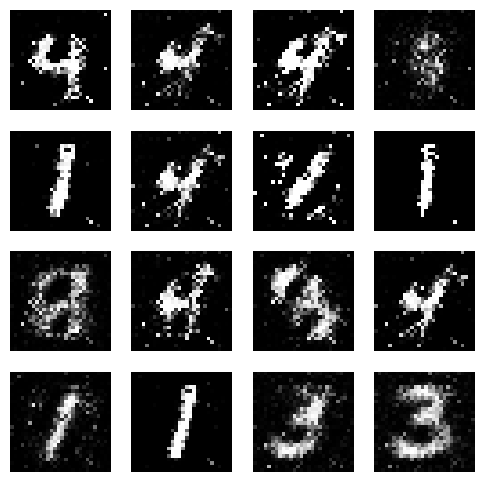

In [ ]:
noise = torch.randn(16, latent_dim).to(device)
generated_images = G(noise).view(-1, 28, 28).detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')

plt.show()
